In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('q3_retail_promotions.csv')
df.head()
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


New temporal features such as year, month, day_of_week, and is_month_end were created from transaction_date to capture seasonal patterns in sales.

In [5]:
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

A temporal split is used instead of a random split to avoid data leakage. This ensures the model is trained on past data and tested on future data, reflecting real-world scenarios.

In [6]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [
    'store_id', 'competition_density',
    'is_weekend', 'is_festival',
    'year', 'month', 'day_of_week', 'is_month_end'
]

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [8]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', LinearRegression())])

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression
y_pred_lr = lr_pipeline.predict(X_test)
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))

# Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))

LR RMSE: 27.121451164890622
LR MAE: 21.052926674588388
RF RMSE: 31.765687633566714
RF MAE: 25.253833333333333


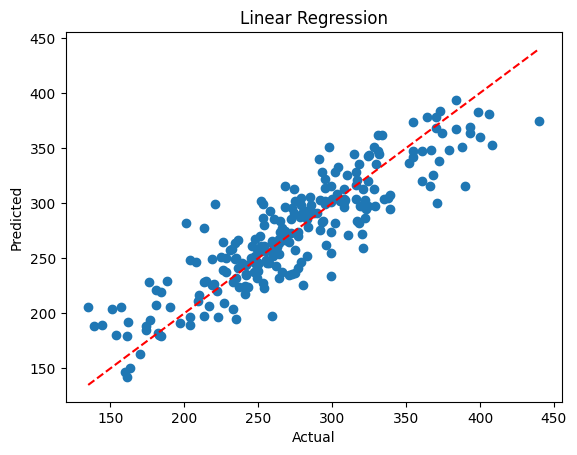

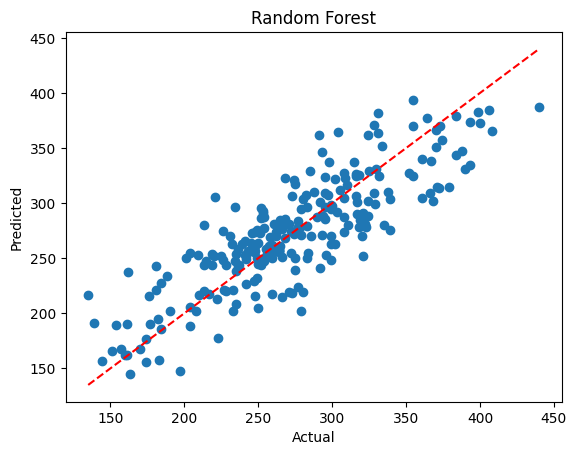

In [11]:
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [12]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
7,cat__store_size_small,0.185726
11,num__is_festival,0.174140
5,cat__location_type_urban,0.141743
14,num__day_of_week,0.092809
8,num__store_id,0.063208


The Random Forest model highlights the most important features influencing items_sold. The top features indicate key drivers such as promotions, store characteristics, and competition.